In [6]:
import fastf1
import pandas as pd
import numpy as np

fastf1.Cache.enable_cache("../cache")


In [7]:
from fastf1 import get_session

session = get_session(2024, "Bahrain", "R")
session.load()


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


In [8]:
laps = session.laps
laps.columns


Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [9]:
quick_laps = laps.pick_quicklaps()
quick_laps.shape


(992, 31)

In [10]:
time_cols = [
    'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time'
]

for col in time_cols:
    quick_laps[col + 'Sec'] = quick_laps[col].dt.total_seconds()

quick_laps[['LapTimeSec', 'Sector1TimeSec']].head()


C:\Users\pavan\AppData\Local\Temp\ipykernel_17492\2871475109.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_laps[col + 'Sec'] = quick_laps[col].dt.total_seconds()
C:\Users\pavan\AppData\Local\Temp\ipykernel_17492\2871475109.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_laps[col + 'Sec'] = quick_laps[col].dt.total_seconds()
C:\Users\pavan\AppData\Local\Temp\ipykernel_17492\2871475109.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

,LapTimeSec,Sector1TimeSec
0,97.284,NaN
1,96.296,30.916
2,96.753,30.999
3,96.647,30.931
4,97.173,31.255


In [11]:
quick_laps['LapInStint'] = (
    quick_laps
    .groupby(['Driver', 'Stint'])
    .cumcount() + 1
)


C:\Users\pavan\AppData\Local\Temp\ipykernel_17492\3484462852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_laps['LapInStint'] = (


In [12]:
consistency = (
    quick_laps
    .groupby('Driver')['LapTimeSec']
    .std()
    .sort_values()
)

consistency


Driver
ZHO    0.770060
BOT    0.830574
OCO    0.840820
RUS    0.886020
TSU    0.915248
STR    0.925715
HUL    0.969951
MAG    0.985754
NOR    1.006134
PIA    1.039636
PER    1.040073
SAI    1.063609
VER    1.079794
ALB    1.093772
HAM    1.133913
LEC    1.142071
SAR    1.164142
RIC    1.166091
GAS    1.296965
ALO    1.348505
Name: LapTimeSec, dtype: float64

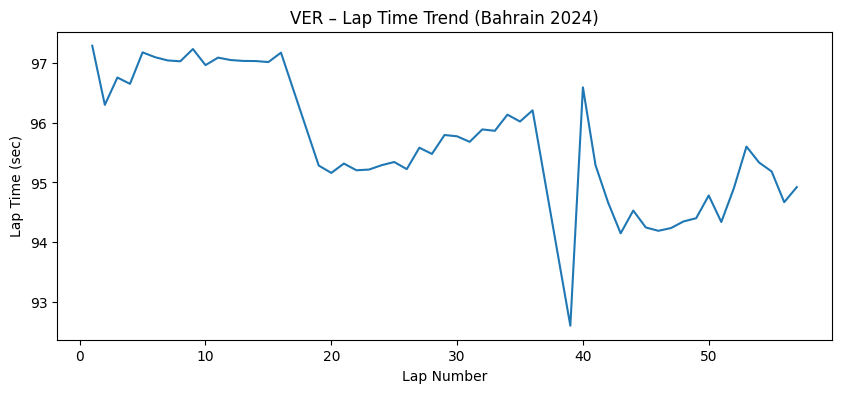

In [13]:
import matplotlib.pyplot as plt

driver = "VER"

driver_laps = quick_laps[quick_laps['Driver'] == driver]

plt.figure(figsize=(10,4))
plt.plot(driver_laps['LapNumber'], driver_laps['LapTimeSec'])
plt.title(f"{driver} – Lap Time Trend (Bahrain 2024)")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (sec)")
plt.show()
